In [1]:
import tensorflow as tf
import numpy as np
import cv2

# 1. Load MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# 2. Preprocess: Resize to 32x32 and convert to 3 channels (RGB)
def preprocess_for_mobilenet(images):
    # Normalize to [0, 1]
    images = images / 255.0
    # Resize to 32x32
    images_resized = np.array([cv2.resize(img, (32, 32)) for img in images])
    # Stack to create 3 channels (None, 32, 32, 3)
    images_rgb = np.stack([images_resized]*3, axis=-1)
    return images_rgb

train_images = preprocess_for_mobilenet(train_images)
test_images = preprocess_for_mobilenet(test_images)

# 3. One-hot encode labels
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

print(f"Input Shape: {train_images.shape}") # Expected: (60000, 32, 32, 3)

Input Shape: (60000, 32, 32, 3)


In [2]:
def build_mobilenet(input_shape=(32, 32, 3)):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights=None, # Training from scratch for MNIST
        alpha=0.35    # Use a smaller width multiplier for MCU efficiency
    )
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

model = build_mobilenet()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_0.35_32             │ (None, 1, 1, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,018 (1.61 MB)

 Trainable params: 408,938 (1.56 MB)

 Non-trainable params: 14,080 (55.00 KB)

In [3]:
# Train for a few epochs
history = model.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 103s 83ms/step - accuracy: 0.7277 - loss: 0.8197 - val_accuracy: 0.1009 - val_loss: 2.3443
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9467 - loss: 0.1814 - val_accuracy: 0.1028 - val_loss: 2.5247
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9632 - loss: 0.1266 - val_accuracy: 0.1028 - val_loss: 2.5147
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9712 - loss: 0.1004 - val_accuracy: 0.1044 - val_loss: 2.5335
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9737 - loss: 0.0943 - val_accuracy: 0.3472 - val_loss: 1.6942
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9747 - loss: 0.0952 - val_accuracy: 0.9693 - val_loss: 0.1178
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9798 - loss: 0.0728 - val_accuracy: 0.9714 - val_loss: 0.1378
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 84ms/step - accuracy: 0.9822 - loss: 0.0624 -

In [4]:
model.save('mobilenet_model.h5')

print("Model saved successfully as mobilenet_model.h5")

Model saved successfully as mobilenet_model.h5


In [5]:
def representative_data_gen():
    # Use 100 samples for calibration
    for i in range(100):
        data = np.expand_dims(train_images[i], axis=0).astype(np.float32)
        yield [data]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Enforce INT8 for both input and output
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_quant = converter.convert()

with open('mobilenet_model.tflite', 'wb') as f:
    f.write(tflite_model_quant)

INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmp1g3ufhrs\assets


INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmp1g3ufhrs\assets


Saved artifact at 'C:\Users\ng822\AppData\Local\Temp\tmp1g3ufhrs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2195444403664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444407696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444407504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444408080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444406544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444408272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444407312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444409040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444407888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2195444406736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  21

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step
Batch Test Accuracy: 98.11%


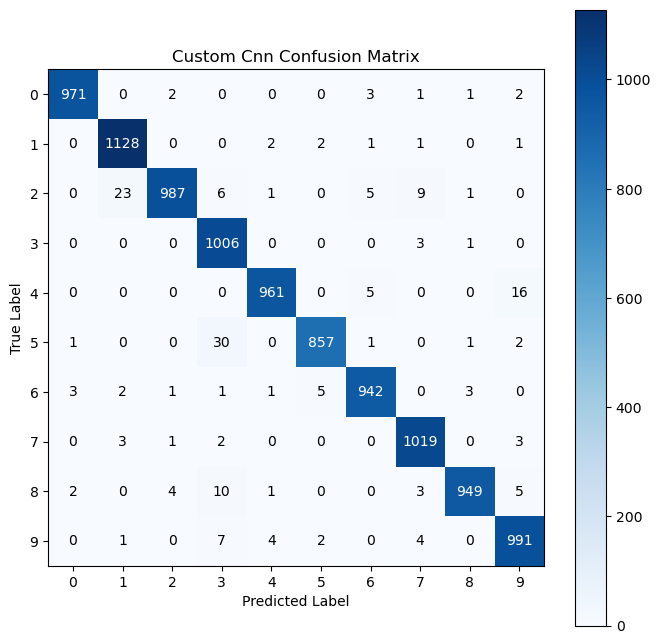

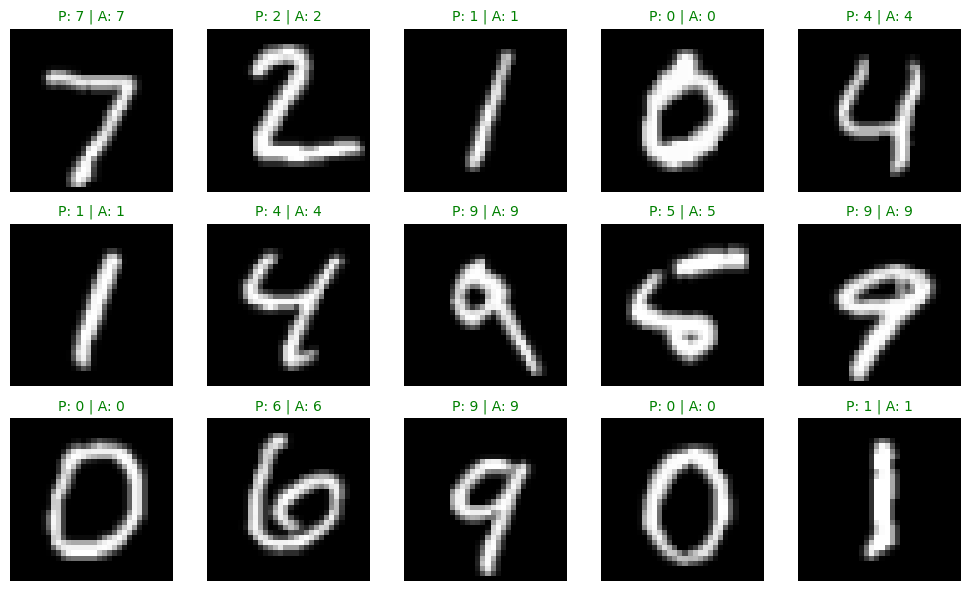

In [6]:
import matplotlib.pyplot as plt
# 1. Get predictions for the entire test set
batch_predictions = model.predict(test_images)
y_pred = np.argmax(batch_predictions, axis=1)
y_true = np.argmax(test_labels, axis=1)

# 2. Calculate accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Batch Test Accuracy: {accuracy * 100:.2f}%")
# 3. Create Confusion Matrix manually
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

# 4. Plot using Matplotlib
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Add labels to the axes
ax.set(xticks=np.arange(num_classes),
       yticks=np.arange(num_classes),
       xticklabels=range(num_classes), 
       yticklabels=range(num_classes),
       title='Custom Cnn Confusion Matrix',
       ylabel='True Label',
       xlabel='Predicted Label')

# Annotate each cell with the numeric value
thresh = cm.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()
# 5. Visualize first 15 results
plt.figure(figsize=(10, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(test_images[i][:,:,0], cmap='gray')
    
    color = 'green' if y_pred[i] == y_true[i] else 'red'
    plt.title(f"P: {y_pred[i]} | A: {y_true[i]}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
import os

def convert_tflite2cc(tflite_path, cc_path, model_name="mobilenet_model"):
    """Converts a TFLite file to a C++ file containing a byte array."""
    with open(tflite_path, 'rb') as f:
        tflite_content = f.read()
    
    hex_line = [f'0x{byte:02x}' for byte in tflite_content]
    
    with open(cc_path, 'w') as f:
        f.write(f'#include "{model_name}.h"\n\n')
        f.write(f'const unsigned char g_{model_name}_data[] = {{\n')
        # Write 12 hex values per line for readability
        for i in range(0, len(hex_line), 12):
            f.write('  ' + ', '.join(hex_line[i:i+12]) + ',\n')
        f.write(f'}};\n\n')
        f.write(f'const int g_{model_name}_data_len = {len(tflite_content)};\n')

# Generate the .cc file
convert_tflite2cc('mobilenet_model.tflite', "mobilenet_model.cc")

In [9]:
def generate_h_file(h_path, model_name="mobilenet_model"):
    with open(h_path, 'w') as f:
        f.write(f'#ifndef {model_name.upper()}_DATA_H_\n')
        f.write(f'#define {model_name.upper()}_DATA_H_\n\n')
        f.write(f'extern const unsigned char g_{model_name}_data[];\n')
        f.write(f'extern const int g_{model_name}_data_len;\n\n')
        f.write(f'#endif // {model_name.upper()}_DATA_H_\n')

# Generate the .h file
generate_h_file("mobilenet_model.h")

In [8]:
interpreter = tf.lite.Interpreter(model_path="mobilenet_model.tflite")
interpreter.allocate_tensors()

print("=== Tensors ===")
for t in interpreter.get_tensor_details():
    print(
        f"name={t['name']}, "
        f"shape={t['shape']}, "
        f"dtype={t['dtype']}"
    )

print("\n=== Ops ===")
for op in interpreter._get_ops_details():
    print(op["op_name"])


=== Tensors ===
name=serving_default_keras_tensor_154:0, shape=[ 1 32 32  3], dtype=<class 'numpy.int8'>
name=arith.constant, shape=[2], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst, shape=[10], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst1, shape=[  10 1280], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst2, shape=[1280], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst3, shape=[1280    1    1  112], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst4, shape=[112], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst5, shape=[112   1   1 336], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst6, shape=[336], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst7, shape=[  1   3   3 336], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst8, shape=[336], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst9, shape=[336   1   1  56], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst10, shape=[56], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst11, shape=[ 56   1   1 336], dtype=

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
